In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import lightgbm as lgb
import xgboost as xgb
import pickle

In [ ]:
products = pd.read_csv("/content/drive/MyDrive/Buynomics Gabriel Galindo/product.csv")
sales = pd.read_csv("/content/drive/MyDrive/Buynomics Gabriel Galindo/sales.csv")

--------------------------
# 1. Familiarise with data:

In [ ]:
products.head()


,Unnamed: 0,brand,flavour,volume_per_joghurt_g,packsize,product_id
0,0,Mueller,blueberry,150,6,0
1,1,Oikos,chocolate,1000,1,1
2,2,Alnatura,strawberry,1000,1,2
3,3,Mueller,straciatella,500,6,3
4,4,Danone,straciatella,150,6,4


In [ ]:
sales.head()

,Unnamed: 0,date,product_id,price,units
0,0,2020-01-01,0,4.65,1126.0
1,1,2020-01-02,0,4.76,1205.0
2,2,2020-01-03,0,5.22,1007.0
3,3,2020-01-04,0,5.45,1282.0
4,4,2020-01-05,0,3.33,1037.0


In [ ]:
products=products.drop("Unnamed: 0", axis=1)
sales=sales.drop("Unnamed: 0", axis=1)

In [ ]:
#products.info()

In [ ]:
#sales.info()

In [ ]:
#products.describe()

In [ ]:
#sales.describe()

In [ ]:
# packsize = products['packsize'].nunique()
# dates = sales['date'].nunique()
# print(packsize,dates)

2 10


--------------------------

# 2. Visualizations:

In [ ]:
final_df = sales.merge(products, on='product_id', how='left')
final_df['date'] = pd.to_datetime(final_df['date'])
final_df.head()

,date,product_id,price,units,brand,flavour,volume_per_joghurt_g,packsize
0,2020-01-01,0,4.65,1126.0,Mueller,blueberry,150,6
1,2020-01-02,0,4.76,1205.0,Mueller,blueberry,150,6
2,2020-01-03,0,5.22,1007.0,Mueller,blueberry,150,6
3,2020-01-04,0,5.45,1282.0,Mueller,blueberry,150,6
4,2020-01-05,0,3.33,1037.0,Mueller,blueberry,150,6


In [ ]:
# Add some representative metrics
final_df['Avg_Price_by_Brand'] = final_df.groupby('brand')['price'].transform('mean')
final_df['Avg_Price_by_Product'] = final_df.groupby('product_id')['price'].transform('mean')
final_df['Total_volum_pack'] = final_df['volume_per_joghurt_g'] * final_df['packsize']

# # Use the date field to get some specific columns
# final_df['day_name'] = final_df['date'].dt.day_name()
# final_df['month'] = final_df['date'].dt.month
# final_df['day_of_week'] = final_df['date'].dt.dayofweek
# final_df['is_weekend'] = final_df['date'].dt.dayofweek.isin([5, 6]).astype(int)

#final_df['month'].unique()
#final_df.info()
display(final_df)

,date,product_id,price,units,brand,flavour,volume_per_joghurt_g,packsize,Avg_Price_by_Brand,Avg_Price_by_Product,Total_volum_pack
0,2020-01-01,0,4.65,1126.0,Mueller,blueberry,150,6,5.59125,4.602,900
1,2020-01-02,0,4.76,1205.0,Mueller,blueberry,150,6,5.59125,4.602,900
2,2020-01-03,0,5.22,1007.0,Mueller,blueberry,150,6,5.59125,4.602,900
3,2020-01-04,0,5.45,1282.0,Mueller,blueberry,150,6,5.59125,4.602,900
4,2020-01-05,0,3.33,1037.0,Mueller,blueberry,150,6,5.59125,4.602,900
...,...,...,...,...,...,...,...,...,...,...,...
255,2020-01-06,26,3.18,1524.0,Oikos,strawberry,500,1,4.21825,3.327,500
256,2020-01-07,26,2.81,1153.0,Oikos,strawberry,500,1,4.21825,3.327,500
257,2020-01-08,26,5.00,913.0,Oikos,strawberry,500,1,4.21825,3.327,500
258,2020-01-09,26,3.38,1603.0,Oikos,strawberry,500,1,4.21825,3.327,500


### Date Conclusion:
Date columns can be really important when doing predictions on sales data. Nevertheless, in the dataset, there's only  data for the first 10 days of January. In this project the Date column would be removed for some reasons. If we decide to train the model with this column, it will probably work and have good results when testing. However, it will only be useful for the first ten days of January. In a real environment, we might need to make a prediction for data in March for example, so in this case the model would give really bad outputs.
For this reason, knowing which data is available and with the objective to create a generic model, the Date field won't be considered. It will be possible to make a prediction in any date of the Year and only considering product features.

In [ ]:
num_cols = final_df.select_dtypes(include="number").columns.tolist()
cat_cols = final_df.select_dtypes(include="object").columns.tolist()

# Move 'packsize' from numeric to categorical
if 'packsize' in num_cols:
    num_cols.remove('packsize')
    cat_cols.append('packsize')

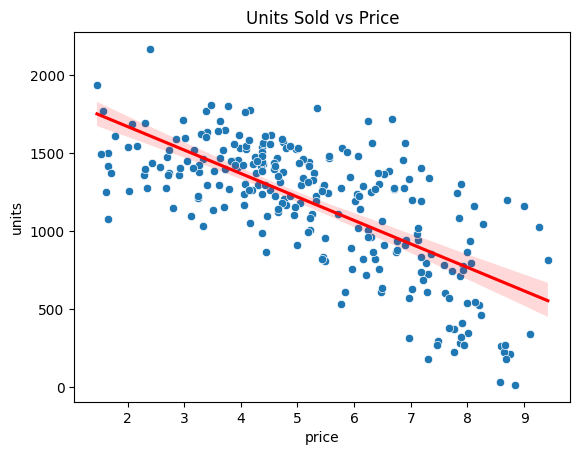

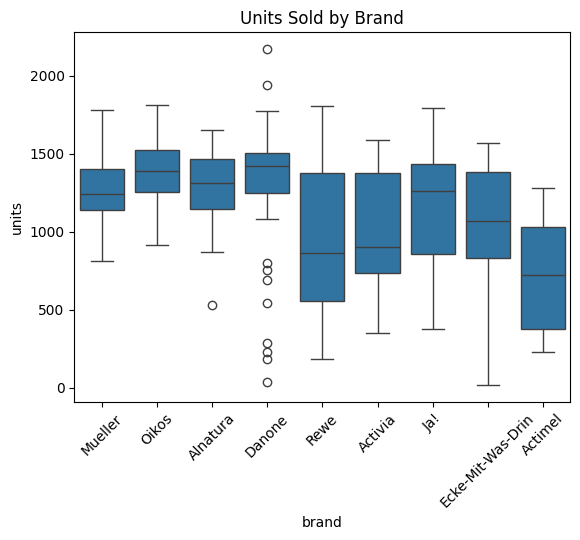

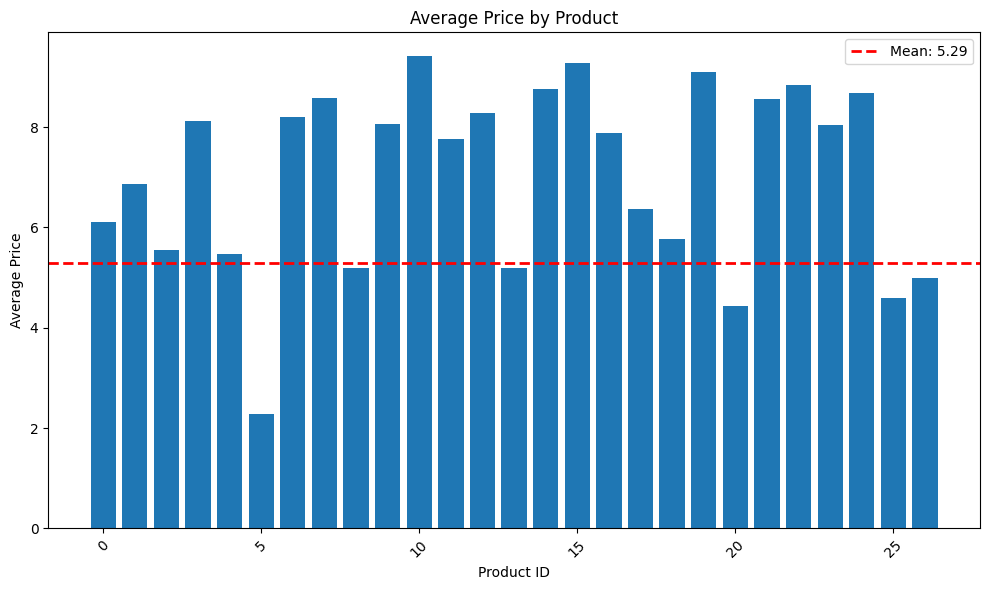

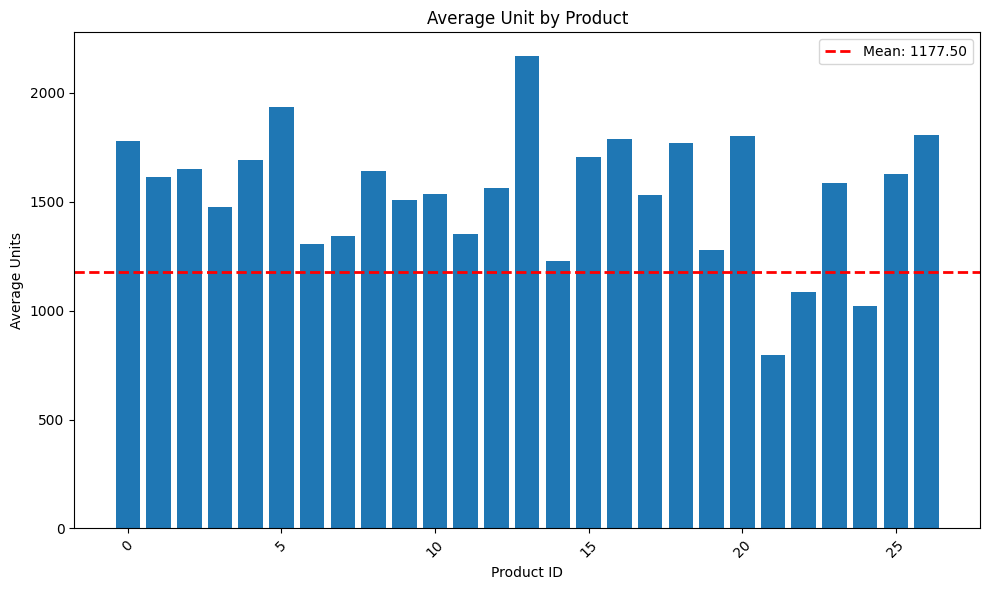

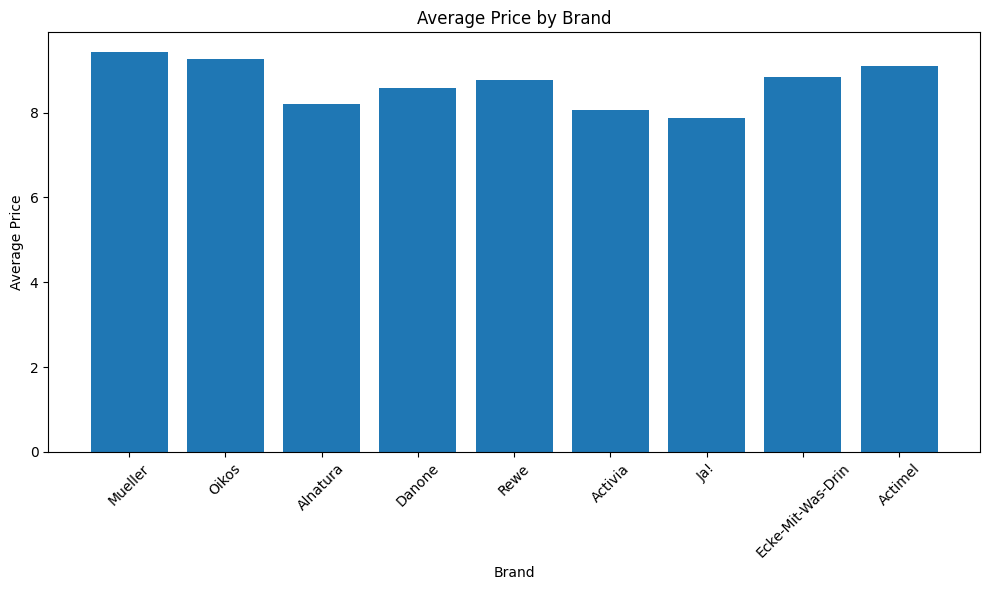

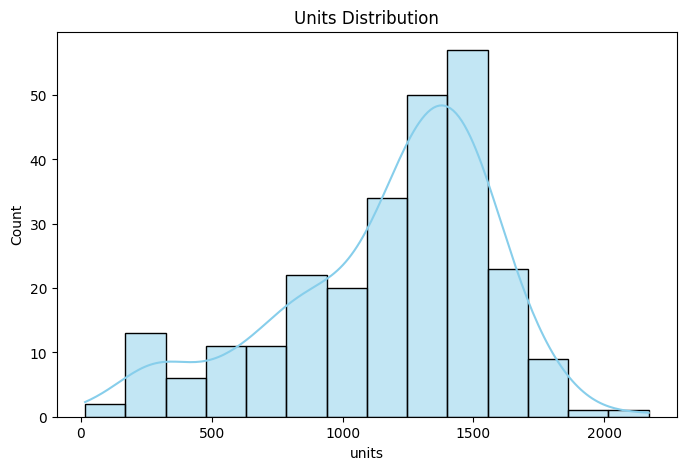

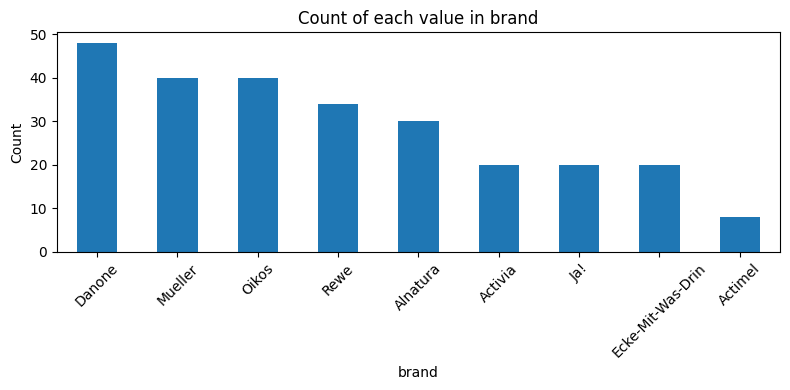

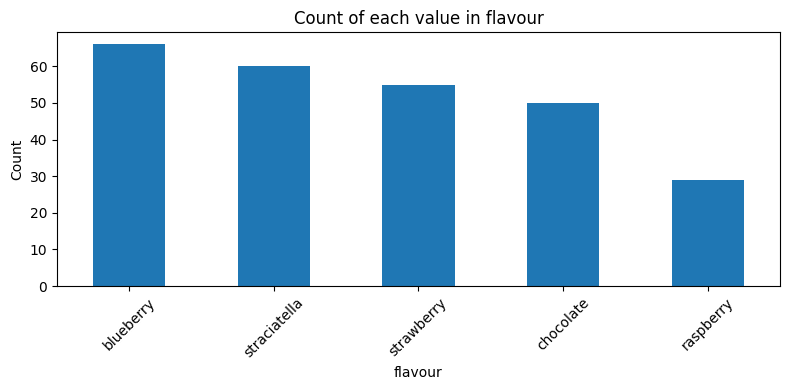

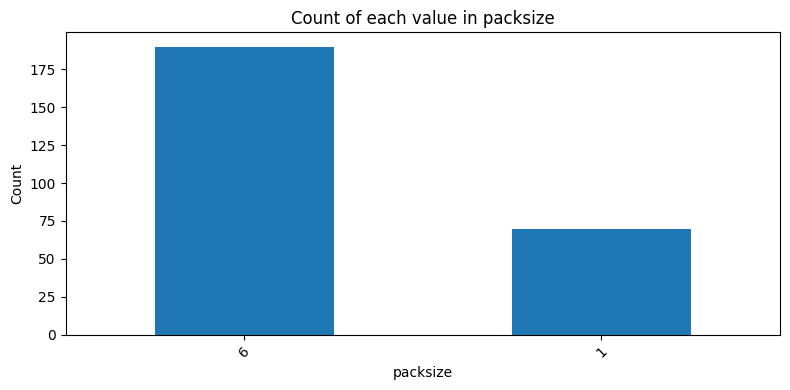

In [ ]:
sns.scatterplot(data=final_df, x='price', y='units')
sns.regplot(data=final_df, x='price', y='units', scatter=False, color='red')
plt.title('Units Sold vs Price')
plt.show()

sns.boxplot(data=final_df, x='brand', y='units')
plt.title('Units Sold by Brand')
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(10, 6))
plt.bar(final_df['product_id'], final_df['price'])
overall_mean = final_df['price'].mean()
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
plt.title('Average Price by Product')
plt.xlabel('Product ID')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.legend()  # show the legend for the mean line
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(final_df['product_id'], final_df['units'])
overall_mean = final_df['units'].mean()
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
plt.title('Average Unit by Product')
plt.xlabel('Product ID')
plt.ylabel('Average Units')
plt.xticks(rotation=45)
plt.legend()  # show the legend for the mean line
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(final_df['brand'], final_df['price'])
plt.title('Average Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SalePrice distribution
plt.figure(figsize = (8,5))
sns.histplot(final_df['units'], kde = True, color = "skyblue")
plt.title("Units Distribution")
plt.show()

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    final_df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of each value in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

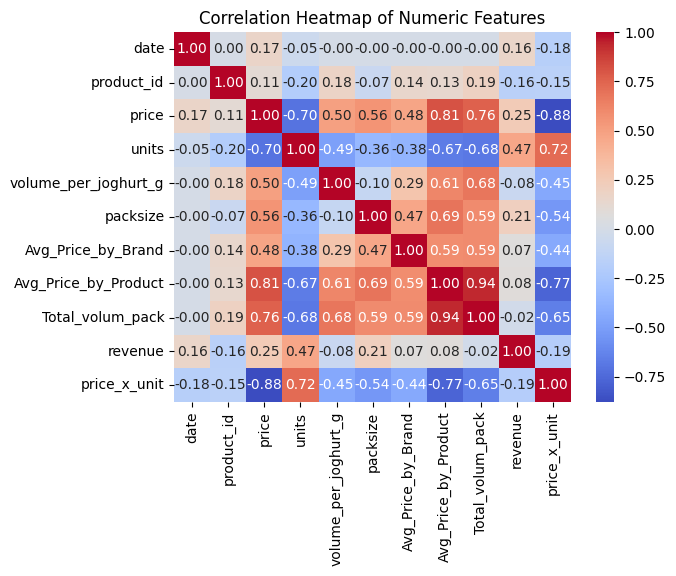

In [ ]:
num_cols = final_df.select_dtypes(include =  ["number", "datetime64"]).columns
plt.figure()
sns.heatmap(final_df[num_cols].corr(), annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


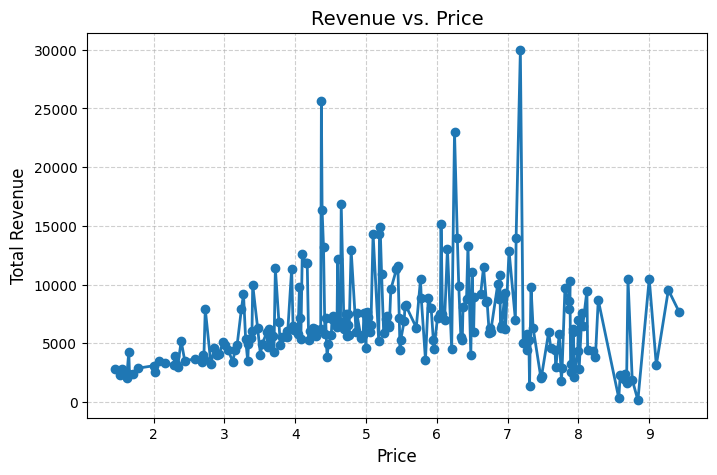

In [ ]:
final_df['revenue'] = final_df['price'] * final_df['units']

revenue_by_price = final_df.groupby('price', as_index=False)['revenue'].sum()

# Sort by price for smooth curve
revenue_by_price = revenue_by_price.sort_values('price')

# Plot
plt.figure(figsize=(8,5))
plt.plot(revenue_by_price['price'], revenue_by_price['revenue'], marker='o', linewidth=2)
plt.title('Revenue vs. Price', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



# Conclusions:
Based on the different analysis and charts that have been made, we can extract different key insights and conclusions:


*   Several columns can be removed: The Unnamed:0 column in both initial datasets works as an index, so it can be removed. Moreover, by doing a further analysis on the Date column, it's seen that there's only 10 days of data, so it does not provide meaningful information. We can double check this by adding it to the correlation chart.
*   When checking the Packsize column, we can see that it only has two values "1" and "6". Despite the fact that it's a numerical column, we will consider it as categorical for the model training. That's because it makes more sense to think that 1 and 6 as numbers might be pretty close for the model training, but if we consider them as classes, they are two complete different ones.
*   Overall, the dataset does not show significant outliers, indicating a consistent and well-distributed set of values across variables. This can be double checked by looking at the bar plots and box plots.
*   The price is the column that most affects to the Units. In this case, the correlation is negative, so that means that if the Price increases, the Units value tends to decrease. It's important to understand the elasticity of the price, so if increasing the price would considerably affect to the Units or not. That's what we are going to test using a predictive model.
*   By looking at the last line-chart. We can compare how the different mean prices affect to the revenue and which would be the most optimum price to get the highest revenue. That means that at low prices we might have high volume of units but not much revenue. Whereas at high prices the units might decrease as well as the revenue. The optimum mean price should be the one that maximizes the revenue, as seen in the chart.







